# <center>Metody Numeryczne</center>

# Laboratorium 7: Pierwiastki wielomianu i wartości własne


**Wykonał:** \<imię i nazwisko\>

<br>

### **Metoda zaliczenia:**

Podczas zajęć należy wykonać poniższe polecenia oraz udzielić odpowiedzi na pytania zamieszczone w treści zadań. 

Wszystkie funkcje wymagane w ramach ćwiczenia należy zaimplementować w pliku `main.py`. Poprawność ich działania należy zweryfikować za pomocą testów jednostkowych dostępnych w pliku `test_main.py`.

### **Cel zajęć:**

Celem zajęć jest zapoznanie się z numerycznymi metodami rozwiązywania równań nieliniowych. W związku z tym podczas zajęć będziemy rozważać następujący problem:

Dana jest funkcja $f(x)$. Należy wyznaczyć takie jej argumenty $x^*$, dla których zachodzi równość $f(x^*) = 0$. 

Argumenty spełniające powyższe równanie nazywane są *pierwiastkami równania*.

<br>

**Wielomian**

Dany jest wielomian $w(x)$ w postaci kanonicznej (ogólnej):

$$
w(x) = a_nx^n + a_{n-1}x^{n-1} + \ldots + a_2x^2 + a_1x + a_0
$$

jego wektor współczynników wyraża się wzorem:

$$
\mathbf{a} = (a_0, a_1, ..., a_{n-1}, a_n)
$$


### **Uwagi wstępne:**
- Funkcje wymagające implementacji (lub zaimplementowane na poprzednich laboratoriach) oznaczone są pochyłą czcionką maszynową (np. *`my_func()`*).

- W skrypcie stosuje się następujące skróty:

    - `np` - `numpy`,
    - `sp` - `scipy`,
    - `nppoly` - `numpy.polynomial.polynomial`.

---

In [20]:
# !python -m pip install numpy scipy matplotlib

import main

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import numpy.polynomial.polynomial as nppoly

---

### **Zadanie 1.**

Dane są wielomiany w postaci iloczynowej:
$$
\begin{align*}
w_1(x) &= (x-1)(x-2)(x-3)\\
w_2(x) &= (x-1)(x-2) \cdot \ldots \cdot (x-20)
\end{align*}
$$

**Punkt 1.**

1. Oblicz wektor współczynników $\mathbf{a}_1$ wielomianu $w_1(x)$ w postaci kanonicznej dla zadanego wektora pierwiastków.

2. Sprawdź poprawność wyznaczonego wektora z definicją w sekcji **Cel zajęć**.

> **Wskazówka:** Użyj funkcji [`nppoly.polyfromroots()`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.polyfromroots.html).

<br>

**Punkt 2.**

Zaimplementuj funkcję *`roots_20()`* wyznaczającą miejsca zerowe wielomianu na podstawie jego wektora współczynników. Funkcja powinna najpierw lekko zaburzać wejściowe współczynniki za pomocą dodania do nich losowej wartości postaci: $N(0,1) \cdot 1\mathrm{e}{-10}$.

> **Wskazówka:** Użyj funkcji [`np.random.random_sample()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.random_sample.html) oraz [`nppoly.polyroots()`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.polyroots.html).

<br>

**Punkt 3.**

1. Wyznacz wektor współczynników $\mathbf{a}_2$ wielomianu $w_2(x)$.

2. W pętli 20 iteracji:
    
    1. Wyznacz pierwiastki zaburzonego wielomianu używając *`roots_20()`*.

    2. Ustaw zaburzony wektor współczynników jako nowy wektor współczynników.

    3. Wyrysuj na jednym wykresie wyznaczone części rzeczywiste pierwiastków, a na drugim części urojone (w każdej iteracji dorysowuj pierwiastki na tym samym rysunku).

4. Określ, które pierwiastki są najbardziej wrażliwe na zaburzenia oraz opisz wnioski wynikające z utworzonego wykresu.

5. Zaproponuj sposób oszacowania uwarunkowania każdego z pierwiastków.


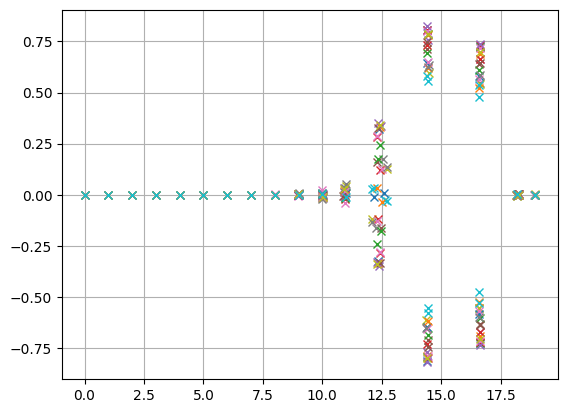

In [21]:
# ===== Twoja implementacja tutaj =====
roots1 = np.array([1, 2, 3])
a1 = nppoly.polyfromroots(roots1)

def roots_20(coef: np.ndarray) -> tuple[np.ndarray, np.ndarray] | None:
    try:
        if np.ndim(coef)!=1:
            return None
        if not isinstance(coef, np.ndarray):
            return None
        coef_kopia= coef.astype(np.complex128) #pracujemy na kopii zeby nie modyfikowac oryginalui
        coef_kopia += np.random.random_sample(coef.shape)*1e-10
        roots_found = nppoly.polyroots(coef_kopia)
        return coef_kopia, roots_found

    except(ValueError,TypeError):
        return None
roots2= np.arange(20)
a2 = nppoly.polyfromroots(roots2)
result = roots_20(a2)
if result is not None:
    coef_1, roots_found_1=result
for i in range(20):
    result_loop = roots_20(coef_1)
    coef_loop, roots_found_loop=result_loop

    plt.plot(np.real(roots_found_loop),np.imag(roots_found_loop), 'x')
plt.show
plt.grid(True)

    




---

### **Zadanie 2.**

Na podstawie wiedzy z wykładu wiadomo, że wartości własne macierzy kwadratowej są pierwiastkami wielomianu charakterystycznego tej macierzy oraz, że każdy wielomian posiada swoją macierz stowarzyszoną (macierz Frobeniusa). Wynika z tego, że **poszukiwanie pierwiastków wielomianu jest równoważne poszukiwaniu wartości własnych macierzy stowarzyszonej**.

<br>

Dany jest wielomian:
$$
w_3(x) = (x-1)^8
$$ 

Należy wyznaczyć numerycznie jego miejsca zerowe na różne sposoby i porównać otrzymane wyniki z wartościami analitycznymi.

**Punkt 1.**

Przygotowanie macierzy stowarzyszonej.

1. Zaiplementuj funkcję *`frob_a()`* tworzącą [macierz Frobeniusa](https://en.wikipedia.org/wiki/Companion_matrix) dla zadanego wektora współczynników wielomianu.

2. Wyznacz macierz Frobeniusa $\mathbf{F_{w_3}}$ dla wielomianu $w_3(x)$.

<br>

**Punkt 2.**

Wyznaczenie pierwiastków wielomianu.

1. Wyznacz wartości własne macierzy $\mathbf{F_{w_3}}$ za pomocą funkcji [`np.linalg.eigvals()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eigvals.html).  

2. Dokonaj rozkładu Schura macierzy $\mathbf{F_{w_3}}$ i na tej podstawie wyznacz wartości własne macierzy $\mathbf{F_{w_3}}$. Użyj funkcji [`sp.linalg.schur()`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.schur.html).

3. Wyznacz pierwiastki wielomianu $w_3(x)$ przy użyciu funkcji [`nppoly.polyroots()`](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.polyroots.html).

<br>

**Punkt 3.**

Zestawienie wyników.

1. Utwórz wykres typu *scatter plot* i wyrysuj na nim wartości pierwiastków wyznaczonych w **Punkcie 2.** oraz pierwiastki oblicznone analitycznie na płaszczyźnie zespolonej.

2. Opisz wnioski wynikające z wykresu.

Wartości własne z macierzy Frobeniusa (eigvals)
[1.01904738+0.00796691j 1.01904738-0.00796691j 1.00770347+0.01904716j
 1.00770347-0.01904716j 0.99203361+0.01878426j 0.99203361-0.01878426j
 0.98121553+0.00770398j 0.98121553-0.00770398j]

Wartości własne z rozkładu Schur
[1.01896519+0.00796366j 1.00763966+0.01898228j 0.9920388 +0.01868756j
 1.01898218-0.00791991j 0.98129171+0.00764208j 0.98131261-0.00768975j
 1.0076834 -0.01896141j 0.99208646-0.01870452j]

Pierwiastki obliczone z wielomianu
[0.97789688-0.00901967j 0.97789688+0.00901967j 0.99051571-0.02210196j
 0.99051571+0.02210196j 1.00901686-0.02256938j 1.00901686+0.02256938j
 1.02257054-0.00948709j 1.02257054+0.00948709j]


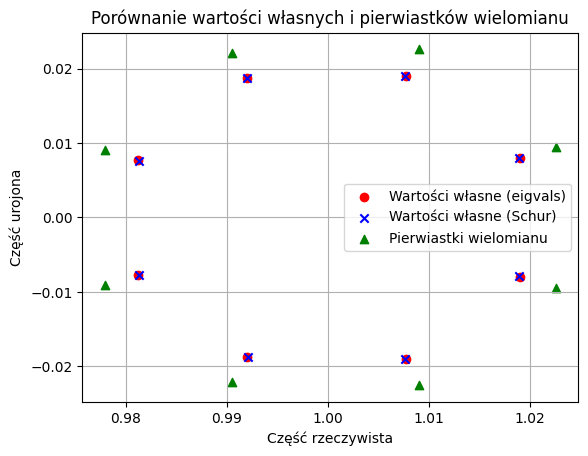

In [22]:
# ===== Twoja implementacja tutaj =====
roots3 = np.ones(8)
a3 = nppoly.polyfromroots(roots3)
def frob_a(coef: np.ndarray) -> np.ndarray | None:
    try:
        if np.ndim(coef)!=1:
            return None
        if not isinstance(coef, np.ndarray):
            return None
        if coef.size < 2:
            return None
        
        n = coef.size - 1 
        a_n = coef[-1]
        if a_n == 0:
            return None
        frob_matrix = np.zeros((n, n))
        for i in range(n-1):
            frob_matrix[i, i + 1] = 1
        frob_matrix[-1, :] = -coef[:-1] / a_n # ZmiaNa ostatniego wiersza w sposob jak w przykladzie
        return frob_matrix

    except(ValueError,TypeError):
        return None
frob_matrix_w3 = frob_a(a3)
wartosci_wlasne_1 = np.linalg.eigvals(frob_matrix_w3)
T,Z = sp.linalg.schur(frob_matrix_w3,output='complex') # output='complex'  musi byc bo inaczej gubimy czesci urojone
wartosci_wlasne_2 = np.diag(T)
pierwiastki_3 = nppoly.polyroots(a3)
print("Wartości własne z macierzy Frobeniusa (eigvals)")
print(wartosci_wlasne_1)
print("\nWartości własne z rozkładu Schur")
print(wartosci_wlasne_2)
print("\nPierwiastki obliczone z wielomianu")
print(pierwiastki_3)
plt.scatter(np.real(wartosci_wlasne_1), np.imag(wartosci_wlasne_1), color='red', label='Wartości własne (eigvals)')
plt.scatter(np.real(wartosci_wlasne_2), np.imag(wartosci_wlasne_2), color='blue', marker='x', label='Wartości własne (Schur)')
plt.scatter(np.real(pierwiastki_3), np.imag(pierwiastki_3), color='green', marker='^', label='Pierwiastki wielomianu')
plt.xlabel('Część rzeczywista')
plt.ylabel('Część urojona')
plt.title('Porównanie wartości własnych i pierwiastków wielomianu')
plt.legend()
plt.grid(True)
plt.show()  

---

### **Zadanie 3.**

Dany jest wielomian:
$$
w_4(x) = 243x^7 - 486x^6 + 783x^5 - 990x^4 + 558x^3 - 28x^2 - 72x + 16
$$ 

1. Wyznacz numerycznie miejsca zerowe wielomianu $w_4(x)$ w sposób analogiczny jak w **Zadaniu 2.**

2. Wyrysuj na płaszczyźnie zespolonej wyznaczone pierwiastki oraz pierwiastki wyliczone analitycznie.

3. Porównaj otrzymane wyniki z rezulatatami otrzymanymi w **Zadaniu 2.**

>**Wskazówka:** Sprawdź poprawność wyznaczonego wektora współczynników z definicją w sekcji **Cel zajęć**.

Pierwiastki z macierzy Frobeniusa:
[ 5.55111512e-17+1.41421356e+00j  5.55111512e-17-1.41421356e+00j
 -3.33333333e-01+0.00000000e+00j  6.66671741e-01+0.00000000e+00j
  6.66664129e-01+4.39477169e-06j  6.66664129e-01-4.39477169e-06j
  3.33333333e-01+0.00000000e+00j]

Pierwiastki z wielomianu:
[-3.33333333e-01+0.00000000e+00j  1.46757606e-15-1.41421356e+00j
  1.46757606e-15+1.41421356e+00j  3.33333333e-01+0.00000000e+00j
  6.66660600e-01+0.00000000e+00j  6.66669700e-01-5.25437970e-06j
  6.66669700e-01+5.25437970e-06j]


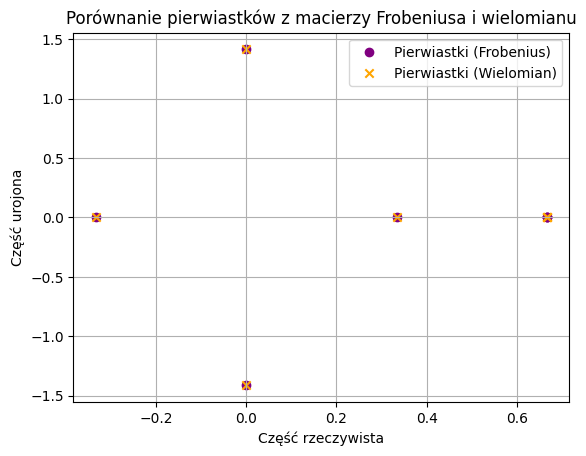

In [23]:
# ===== Twoja implementacja tutaj =====
wspolczynniki = np.array([243,-486,783,-990,558,-28,-72,16])
a4 = np.flip(wspolczynniki) # Odwracamy kolejność współczynników
frob_matrix_w4 = frob_a(a4)
roots_frob_w4 = np.linalg.eigvals(frob_matrix_w4)
roots_poly_w4 = nppoly.polyroots(a4)
print("Pierwiastki z macierzy Frobeniusa:")
print(roots_frob_w4)
print("\nPierwiastki z wielomianu:")
print(roots_poly_w4)
plt.scatter(np.real(roots_frob_w4), np.imag(roots_frob_w4), color='purple', label='Pierwiastki (Frobenius)')
plt.scatter(np.real(roots_poly_w4), np.imag(roots_poly_w4), color='orange', marker='x', label='Pierwiastki (Wielomian)')
plt.xlabel('Część rzeczywista')
plt.ylabel('Część urojona')   
plt.title('Porównanie pierwiastków z macierzy Frobeniusa i wielomianu')
plt.legend()
plt.grid(True)
plt.show()



---

### **Zadanie 4.**

Zadanie polega na przeanalizowaniu w jaki sposób różne przekształcenia macierzy wpływają na pojawianie się błędów numerycznych.

W celu przeprowadzenia analizy skonstruuj trzy macierze diagonalne $\mathbf{A}_n$ dla $n = \{10,20,30\}$. Współczynniki macierzy powinny być zdefiniowane jako $a_{ii} = 2^i$ dla $i = \{1,2,...,n\}$ (skorzystaj z funkcji [`np.diag()`](https://numpy.org/doc/stable/reference/generated/numpy.diag.html)).

**Punkt 1.**

1. Dla każdej z macierzy $\mathbf{A}_n$ oblicz wartości własne przy użyciu [`np.linalg.eigvals()`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.linalg.eigvals.html) i porównaj je z wartościami własnymi wyznaczonymi analitycznie.

<br>

**Punkt 2.**

1. Zdefiniuj funcję *`is_nonsingular()`* sprawdzającą czy zadana macierz nie jest singularna. 

2. Skonstruuj losowe niesingularne macierze wektorów własnych $\mathbf{P}_n$, których wartości współczynników są liczbami całkowitymi z zakresu $(0,100)$. Na podstawie macierzy $\mathbf{A}_n$ i $\mathbf{P}_n$ oblicz macierze $\mathbf{B}_n$ postaci: 
$$
\mathbf{B}_n = \mathbf{P}_n\mathbf{A}_n\mathbf{P}_{n}^{-1}
$$ 

3. Oblicz wartości własne macierzy dla uzyskanych macierzy $\mathbf{B}_n$ i porównaj je z wartościami własnymi wyznaczonymi analitycznie.

>**Wskazówka:** Niesingularność macierzy $\mathbf{P}_n$ można zapewnić generując je w pętli, w której warunkiem stopu będzie wynik funkcji zaimplementowanej w **Podpunkcie 1.**

<br>

**Punkt 3.**

1. Bazując na macierzach $\mathbf{P}_n$ wygeneruj macierze ortogonalne $\mathbf{Q}_n$ (można do tego użyć rozkładu QR). Na podstawie macierzy $\mathbf{A}_n$ i $\mathbf{Q}_n$ oblicz macierze $\mathbf{C}_n$ postaci:
$$
\mathbf{C}_n = \mathbf{Q}_n\mathbf{A}_n\mathbf{Q}_{n}^{-1}
$$

2. Oblicz wartości własne macierzy dla uzyskanych macierzy $\mathbf{C}_n$ i porównaj je z wartościami własnymi wyznaczonymi analitycznie.

<br>

**Punkt 4.**

1. Bazując na analitycznych wartościach własnych dla wielomianów charakterystycznych macierzy $\mathbf{A}_n$ wygeneruj macierze Frobeniusa $\mathbf{F}_n$ korzystając z funkcji zaimplementowanej w **Zadaniu 2.** 

2. Oblicz wartości własne macierzy dla uzyskanych macierzy $\mathbf{F}_n$ i porównaj je z wartościami własnymi wyznaczonymi analitycznie.

<br>

**Punkt 5.**

Porównaj wyniki otrzymane we wszystkich punktach. Opisz z czego wynikają powstałe błędy obliczeń.

In [24]:
# ===== Twoja implementacja tutaj =====
n_values = [10, 20, 30]
A = {}
analytic_eigvals = {}
numeric_eigvals = {}

for n in n_values:
    diagonal_values = 2.0 ** np.arange(n) 
    A[n] = np.diag(diagonal_values)
    
    analytic_eigvals[n] = diagonal_values
    
    numeric_eigvals[n] = np.linalg.eigvals(A[n])

    error = np.abs(numeric_eigvals[n] - analytic_eigvals[n]) / analytic_eigvals[n]
    print(f"Błąd względny dla n={n}:")
    print(error)

def is_nonsingular(A: np.ndarray) -> bool | None: 
    try:
        if not isinstance(A, np.ndarray) or A.ndim != 2 or A.shape[0] != A.shape[1]:
            return None
        det_A = np.linalg.det(A)
        eps_machine = np.finfo(float).eps
        if abs(det_A) > eps_machine:
            return True
        else:
            return False
    except(ValueError,TypeError):
            return None
    
P = {}
B = {}
numeric_eigvals_B = {}

for n in n_values:
    P[n] = np.zeros((n, n))
    while not is_nonsingular(P[n]):
        P[n] = np.random.randint(1, 101, size=(n, n)).astype(float) # Zakres (0, 100)

    P_inv = np.linalg.inv(P[n])
    B[n] = P[n] @ A[n] @ P_inv
    numeric_eigvals_B[n] = np.linalg.eigvals(B[n])
    
    analytic_sorted = np.sort(analytic_eigvals[n])
    numeric_sorted = np.sort(numeric_eigvals_B[n].real)

    error = np.abs(numeric_sorted - analytic_sorted) / analytic_sorted
    
print(f"Błąd względny dla macierzy B przy n={n}:")
print(error)


Q = {}
C = {}
numeric_eigvals_C = {}

for n in n_values:
    Q[n], R = np.linalg.qr(P[n])
    Q_trans = Q[n].T
    C[n] = Q[n] @ A[n] @ Q_trans

    numeric_eigvals_C[n] = np.linalg.eigvals(C[n])
    analytic_sorted = np.sort(analytic_eigvals[n])
    numeric_sorted = np.sort(numeric_eigvals_C[n].real)

    error = np.abs(numeric_sorted - analytic_sorted) / analytic_sorted
    print(f"Błąd względny dla macierzy C przy n={n}:")
    print(error)

numeric_eigvals_F = {}
for n in n_values:
    roots = analytic_eigvals[n]
    coeffs_poly = np.poly(roots) 
    coef_dla_frob = coeffs_poly[::-1] 
    F = frob_a(coef_dla_frob)
    numeric_eigvals_F[n] = np.linalg.eigvals(F)

    analytic_sorted = np.sort(roots)
    numeric_sorted = np.sort(numeric_eigvals_F[n].real)
    error = np.abs(numeric_sorted - analytic_sorted) / analytic_sorted
    print(f"Błąd względny dla macierzy F przy n={n}:")
    print(error)

Błąd względny dla n=10:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Błąd względny dla n=20:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Błąd względny dla n=30:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Błąd względny dla macierzy B przy n=30:
[1.20675465e-08 5.05710228e-07 9.63232309e-08 4.92989758e-08
 1.52070698e-08 1.81283721e-09 1.10140947e-08 2.37789100e-09
 5.34133848e-10 1.79203763e-10 8.43858317e-11 3.00828029e-10
 2.01437200e-10 2.14225526e-10 1.48633328e-11 1.55571112e-11
 3.91453536e-12 3.16036086e-12 1.74127379e-12 2.55462318e-13
 2.48712162e-12 9.23039423e-13 1.39666056e-13 7.77156117e-15
 7.21644966e-14 2.27595720e-14 5.10702591e-15 2.22044605e-15
 1.46549439e-14 3.10862447e-15]
Błąd względny dla macierzy C przy n=10:
[6.66133815e-15 1.99840144e-15 1.11022302e-15 1.11022302e-15
 6.66133815e-16 6.66133815e-16 4.44089210e-16 1.77635684e-15
 2.22044605e-16 8.88178420e-16]
Błąd względny dla macierzy C przy n=20:
[3.99080

**Przykładowa forma zestawienia wyników:**
```python
for i, n in enumerate(n_values):
    print(f"   {'Macierz':<18} {'Błąd maksymalny':<18} {'Błąd średni':<18}")
    print(f"   {'-'*55}")
    print(f"   {'A_' + str(n) + ' (diag)':<18} {max_error_A[i]:<18.2e} {mean_error_A[i]:<18.2e}")
    print(f"   {'B_' + str(n) + ' (P*A*P^-1)':<18} {max_error_B[i]:<18.2e} {mean_error_B[i]:<18.2e}")
    print(f"   {'C_' + str(n) + ' (Q*A*Q^T)':<18} {max_error_C[i]:<18.2e} {mean_error_C[i]:<18.2e}")
    print(f"   {'F_' + str(n) + ' (Frobenius)':<18} {max_error_F[i]:<18.2e} {mean_error_F[i]:<18.2e}\n")
```

**Rezultat:**
```md
   Macierz            Błąd maksymalny    Błąd średni       
   -------------------------------------------------------
   A_10 (diag)        0.00e+00           0.00e+00          
   B_10 (P*A*P^-1)    0.00e+00           0.00e+00          
   C_10 (Q*A*Q^T)     0.00e+00           0.00e+00          
   F_10 (Frobenius)   0.00e+00           0.00e+00          

   Macierz            Błąd maksymalny    Błąd średni       
   -------------------------------------------------------
   A_20 (diag)        0.00e+00           0.00e+00          
   B_20 (P*A*P^-1)    0.00e+00           0.00e+00          
   C_20 (Q*A*Q^T)     0.00e+00           0.00e+00          
   F_20 (Frobenius)   0.00e+00           0.00e+00          

   Macierz            Błąd maksymalny    Błąd średni       
   -------------------------------------------------------
   A_30 (diag)        0.00e+00           0.00e+00          
   B_30 (P*A*P^-1)    0.00e+00           0.00e+00          
   C_30 (Q*A*Q^T)     0.00e+00           0.00e+00          
   F_30 (Frobenius)   0.00e+00           0.00e+00
```

---

**Materiały uzupełniające:**
- [Scipy Lecture Notes](http://www.scipy-lectures.org/index.html)
- [NumPy for Matlab users](https://docs.scipy.org/doc/numpy/user/numpy-for-matlab-users.html#numpy-for-matlab-users)
- [Python Tutorial - W3Schools](https://www.w3schools.com/python/default.asp)
- [NumPy](https://www.numpy.org)
- [Matplotlib](https://matplotlib.org/)
- [Anaconda](https://www.anaconda.com/)
- [Learn Python for Data Science](https://www.datacamp.com/learn-python-with-anaconda?utm_source=Anaconda_download&utm_campaign=datacamp_training&utm_medium=banner)
- [Learn Python](https://www.learnpython.org/)
- [Wujek Google](https://google.pl) i [Ciocia Wikipedia](https://pl.wikipedia.org/wiki/Wikipedia:Strona_g%C5%82%C3%B3wna)